<a href="https://colab.research.google.com/github/lodigasatish-ai/teleconnect-ml-assignment/blob/main/notebooks/03_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training Logistic Regression = 


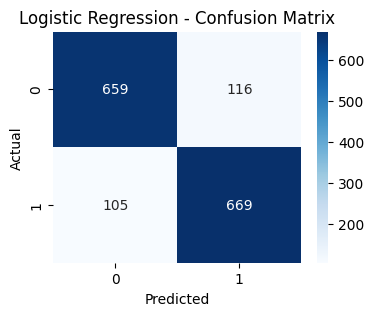

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       775
           1       0.85      0.86      0.86       774

    accuracy                           0.86      1549
   macro avg       0.86      0.86      0.86      1549
weighted avg       0.86      0.86      0.86      1549


Training Decision Tree = 


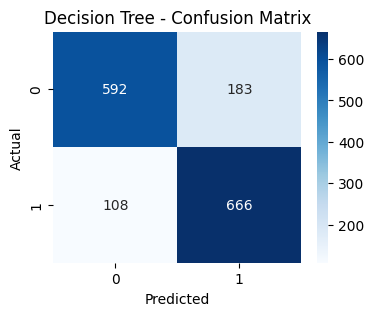

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       775
           1       0.78      0.86      0.82       774

    accuracy                           0.81      1549
   macro avg       0.82      0.81      0.81      1549
weighted avg       0.82      0.81      0.81      1549


Training Random Forest = 


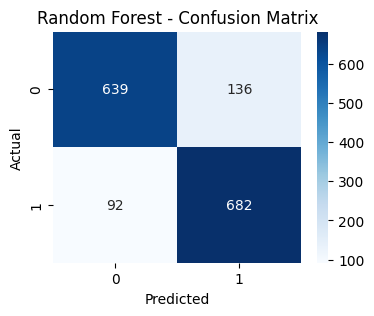

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       775
           1       0.83      0.88      0.86       774

    accuracy                           0.85      1549
   macro avg       0.85      0.85      0.85      1549
weighted avg       0.85      0.85      0.85      1549


Training SVM = 


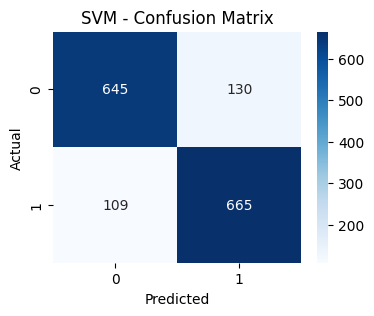

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       775
           1       0.84      0.86      0.85       774

    accuracy                           0.85      1549
   macro avg       0.85      0.85      0.85      1549
weighted avg       0.85      0.85      0.85      1549


Training KNN = 


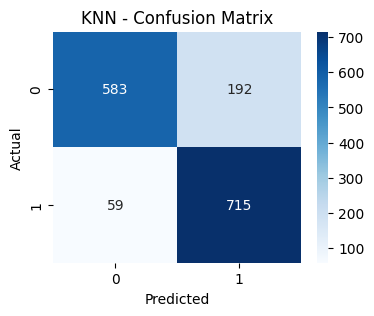

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       775
           1       0.79      0.92      0.85       774

    accuracy                           0.84      1549
   macro avg       0.85      0.84      0.84      1549
weighted avg       0.85      0.84      0.84      1549



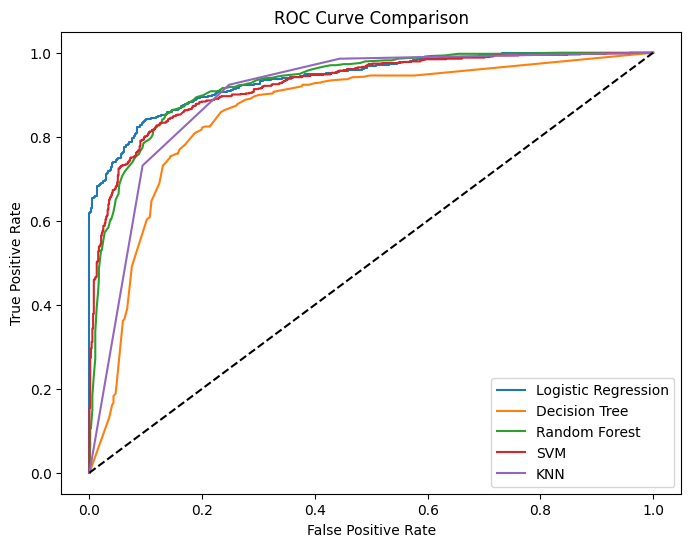


Final Comparison Table:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC    Time
0  Logistic Regression     0.857      0.852   0.864  0.858    0.938   1.819
1        Decision Tree     0.812      0.784   0.860  0.821    0.858   0.696
2        Random Forest     0.853      0.834   0.881  0.857    0.928   7.522
3                  SVM     0.846      0.836   0.859  0.848    0.924  43.616
4                  KNN     0.838      0.788   0.924  0.851    0.901   0.720

Best Model: Logistic Regression


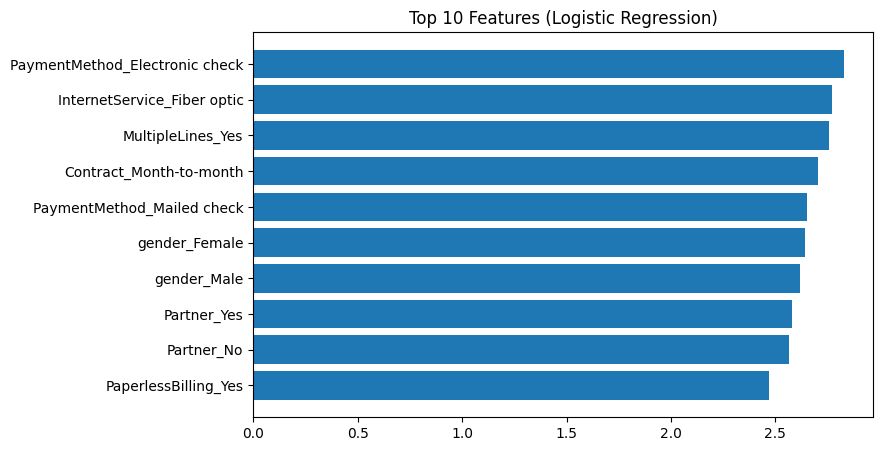


Task 3 completed successfully.


In [ ]:
# Task 3: Classification — Churn Prediction

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Models
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {'C': [0.1, 1]}),
    "Decision Tree": (DecisionTreeClassifier(), {'max_depth': [5, 10]}),
    "Random Forest": (RandomForestClassifier(), {'n_estimators': [50, 100]}),
    "SVM": (SVC(probability=True), {'C': [0.1, 1]}),
    "KNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5]})
}

results = []
best_models = {}

# Store ROC values
roc_data = []

# Training Loop
for name, (model, params) in models.items():
    print(f"\nTraining {name} = ")

    start = time.time()

    grid = GridSearchCV(model, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    time_taken = time.time() - start

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc, time_taken])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Store ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data.append((name, fpr, tpr))

# ROC Curve Plot
plt.figure(figsize=(8,6))

for name, fpr, tpr in roc_data:
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Results Table
results_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1","ROC-AUC","Time"
])

print("\nFinal Comparison Table:")
print(results_df.round(3))

# Best Model
best_name = results_df.sort_values(by="F1", ascending=False).iloc[0]['Model']
print("\nBest Model:", best_name)
best_model = best_models[best_name]

# Feature Importance
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    features = X_train.columns

elif hasattr(best_model, "coef_"):
    importances = abs(best_model.coef_[0])
    features = X_train.columns

else:
    importances = None


if importances is not None:
    imp_df = pd.DataFrame({
        "Feature": features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(10)

    plt.figure(figsize=(8,5))
    plt.barh(imp_df["Feature"], imp_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Features ({best_name})")
    plt.show()
else:
    print("Feature importance not available")


print("\nTask 3 completed successfully.")